# 1.2 Validación de catálogos

**Actividad 1.2**
- Contrasta la base con el catálogo de indicadores y el catálogo de entornos.
- Valida la relación entre ellos y documenta las diferencias.

**Contenido**
- **1.2.a** Indicadores de la base vs catálogo de indicadores
- **1.2.b** Indicadores del catálogo que nadie mide
- **1.2.c** Frentes: base vs catálogo
- **1.2.d** Códigos de equipo: ¿cómo están escritos?
- **1.2.e** Equipos fantasma y equipos sin mediciones
- **1.2.f** ¿A qué entorno pertenece cada equipo?
- **1.2.g** Diferencias documentadas

</br>

| Artefacto | Ruta |
|---|---|
| Entrada | `0_datos/1_crudos/KPIS_historico.xlsx` |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

pd.set_option("display.max_colwidth", 80)

ARCHIVO = Path("../../0_datos/1_crudos/KPIS_historico.xlsx")
VERDE, AMARILLO, NARANJA, ROJO, AZUL, MORADO, ROSADO, GRIS, GRIS_CLARO = (
    "#00c389", "#fdda24", "#ff7f41", "#e03c31", "#59cbe8", "#9063cd", "#f5b6cd", "#9e9a99", "#e6e3e2")

In [2]:
def simplificar(texto):
    """Minúsculas y sin tildes, para detectar nombres que solo difieren en la escritura."""
    return texto.lower().replace("á", "a").replace("é", "e").replace("í", "i").replace("ó", "o").replace("ú", "u")


def limpiar_ejes(ax, lados=("top", "right")):
    ax.spines[list(lados)].set_visible(False)


def barra_apilada(ax, y, valores, colores, texto=lambda grupo, valor: f"{valor:,.0f}", minimo=0):
    """Barra horizontal con un segmento por grupo; los segmentos más angostos que `minimo` llevan el texto afuera."""
    inicio = 0
    for grupo, valor in valores.items():
        if valor == 0:
            continue
        ax.barh(y, valor, left=inicio, color=colores[grupo], edgecolor="white")
        if valor >= minimo:
            ax.text(inicio + valor / 2, y, texto(grupo, valor), ha="center", va="center", fontsize=8)
        else:
            ax.text(inicio + valor, y, " " + texto(grupo, valor), ha="left", va="center", fontsize=8)
        inicio += valor


def leyenda(ax, colores, ncol=5, y=-0.05):
    ax.legend(handles=[Patch(color=c, label=g) for g, c in colores.items()], frameon=False, ncol=ncol,
              loc="upper center", bbox_to_anchor=(0.5, y), fontsize=9)

In [3]:
kpis = pd.read_excel(ARCHIVO, sheet_name="query", dtype={"Corte": str, "Codigo_EQU": str, "EQU": str})
cat_indicadores = pd.read_excel(ARCHIVO, sheet_name="catalogo_indicadores", dtype=str)
cat_entornos = pd.read_excel(ARCHIVO, sheet_name="catalogo_entornos", dtype=str)

# Un mismo equipo aparece escrito de varias formas (Equ00074 / EQU00074, EQU0024 / EQU00024): se unifica para contar equipos
kpis["codigo_equipo"] = kpis["Codigo_EQU"].str.upper().str.replace(r"^([A-Z]{3})0(\d{3})$", r"\g<1>00\2", regex=True)

## 1.2.a Indicadores de la base vs catálogo de indicadores

Cada barra es un indicador de la base: su **largo** son los meses que se ha medido (de 44) y su **color** dice si está en el catálogo. Entre más intenso el color, más tiempo se ha medido: un rojo intenso es un indicador que se usa hace mucho y **nadie ha documentado**.

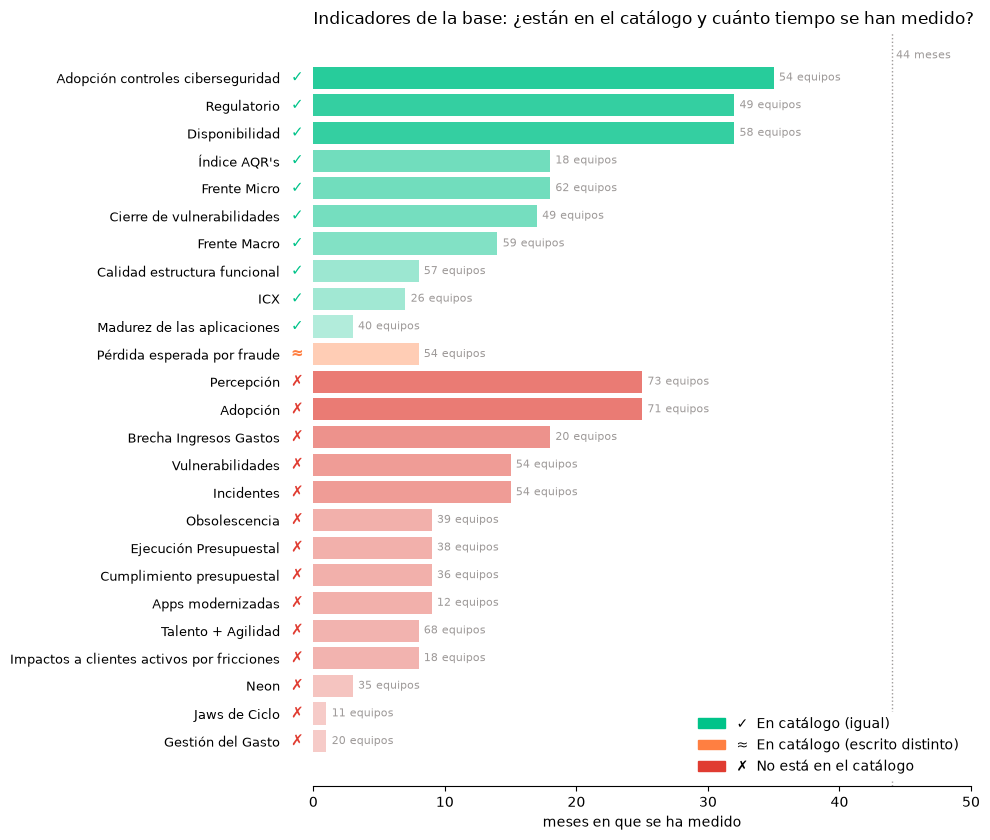

,indicadores,filas,% de filas
estado,,,
En catálogo (escrito distinto),1,417,2.7
En catálogo (igual),10,6504,42.8
No está en el catálogo,14,8267,54.4


In [4]:
por_indicador = (
    kpis.groupby("Indicador")
    .agg(equipos=("codigo_equipo", "nunique"), meses=("Corte", "nunique"), filas=("Corte", "size"))
    .reset_index()
)
nombres_catalogo = set(cat_indicadores["Indicador"])
nombres_catalogo_simple = {simplificar(n) for n in nombres_catalogo}
por_indicador["estado"] = "No está en el catálogo"
por_indicador.loc[por_indicador["Indicador"].map(simplificar).isin(nombres_catalogo_simple), "estado"] = "En catálogo (escrito distinto)"
por_indicador.loc[por_indicador["Indicador"].isin(nombres_catalogo), "estado"] = "En catálogo (igual)"

TOTAL_MESES = kpis["Corte"].nunique()
estilos = {"En catálogo (igual)": (VERDE, "✓"), "En catálogo (escrito distinto)": (NARANJA, "≈"), "No está en el catálogo": (ROJO, "✗")}
orden = por_indicador.assign(grupo=por_indicador["estado"].map(list(estilos).index)).sort_values(["grupo", "meses"], ascending=[False, True])

fig, ax = plt.subplots(figsize=(10, 8.5))
for i, fila in enumerate(orden.itertuples()):
    color, simbolo = estilos[fila.estado]
    ax.barh(i, fila.meses, color=color, alpha=0.25 + 0.75 * fila.meses / TOTAL_MESES)
    ax.text(fila.meses + 0.4, i, f"{fila.equipos} equipos", va="center", fontsize=8, color=GRIS)
    ax.text(-1.2, i, simbolo, va="center", ha="center", fontsize=11, color=color, fontweight="bold")
ax.set_yticks(range(len(orden)), [n[:42] for n in orden["Indicador"]], fontsize=9)
ax.tick_params(axis="y", pad=24, length=0)
ax.axvline(TOTAL_MESES, color=GRIS, ls=":", lw=1)
ax.text(TOTAL_MESES, len(orden) - 0.3, f" {TOTAL_MESES} meses", fontsize=8, color=GRIS)
ax.set_xlim(0, TOTAL_MESES + 6)
ax.set_xlabel("meses en que se ha medido")
ax.legend(handles=[Patch(color=c, label=f"{s}  {e}") for e, (c, s) in estilos.items()],
          loc="lower right", facecolor="white", edgecolor="white", framealpha=1)
ax.set_title("Indicadores de la base: ¿están en el catálogo y cuánto tiempo se han medido?", loc="left")
limpiar_ejes(ax, ("top", "right", "left"))
plt.tight_layout()
plt.show()

resumen = por_indicador.groupby("estado").agg(indicadores=("Indicador", "size"), filas=("filas", "sum"))
resumen["% de filas"] = (resumen["filas"] / len(kpis) * 100).round(1)
display(resumen)

**Lectura:** los 14 indicadores sin definición suman el **54% de las filas**; Percepción y Adopción llevan 25 meses y más de 70 equipos sin documentar. "Pérdida esperada por fraude" solo difiere por una tilde.

## 1.2.b Indicadores del catálogo que nadie mide

In [5]:
indicadores_base_simple = set(kpis["Indicador"].map(simplificar))
sin_equipos = cat_indicadores[~cat_indicadores["Indicador"].map(simplificar).isin(indicadores_base_simple)]
display(sin_equipos[["Frente", "Indicador", "Definición (qué mide y para qué)", "Unidad"]])
print("¿Tienen exactamente la misma definición?:", sin_equipos["Definición (qué mide y para qué)"].nunique() == 1)

,Frente,Indicador,Definición (qué mide y para qué),Unidad
7,Modelos de trabajo y Agilidad,Adopción de la metodologia,"Consolida una mirada integral de la salud de los equipos, combinando la adop...",Escala
8,Modeos de trabajo y Agilidad,Productividad,"Consolida una mirada integral de la salud de los equipos, combinando la adop...",Porcentaje


¿Tienen exactamente la misma definición?: True


**Lectura:** ambos describen un índice consolidado (adopción, percepción, estructura funcional y productividad); la base trae esos componentes por separado. Hipótesis por confirmar con el dueño del catálogo.

## 1.2.c Frentes: base vs catálogo

In [6]:
print("Frentes en la base:     ", sorted(kpis["Frente"].unique()))
print("Frentes en el catálogo: ", sorted(cat_indicadores["Frente"].unique()))
agilidad = kpis[kpis["Frente"].str.contains("Agilidad")]
display(agilidad.groupby("Frente")["Corte"].agg(primer_mes="min", ultimo_mes="max", filas="size").sort_values("primer_mes"))

Frentes en la base:      ['Excelencia operativa', 'Experiencia', 'Financiero', 'Modelos de trabajo y Agilidad', 'Modeos de trabajo y Agilidad', 'Regulatorio', 'TI', 'Talento + Agilidad']
Frentes en el catálogo:  ['Excelencia operativa', 'Experiencia', 'Financiero', 'Modelos de trabajo y Agilidad', 'Modeos de trabajo y Agilidad', 'Regulatorio', 'TI']


,primer_mes,ultimo_mes,filas
Frente,,,
Talento + Agilidad,202301,202412,2672
Modelos de trabajo y Agilidad,202501,202509,2826
Modeos de trabajo y Agilidad,202601,202608,417


**Lectura:** hay tres frentes de agilidad en el tiempo (2023-24, 2025, 2026). "Modeos…" es un error de digitación que también está en el catálogo: la base hereda los errores del catálogo. "Talento + Agilidad" no está en el catálogo y sus indicadores no coinciden con los del frente "Modelos de trabajo y Agilidad", así que no se puede asumir que sea el mismo frente.

## 1.2.d Códigos de equipo: ¿cómo están escritos?

In [7]:
mal_escrito = kpis["Codigo_EQU"].notna() & (kpis["Codigo_EQU"] != kpis["codigo_equipo"])
print("Filas sin código de equipo:", kpis["Codigo_EQU"].isna().sum())
print("Formas distintas de escribir el código:", kpis["Codigo_EQU"].nunique())
print("Equipos reales (mayúsculas y 5 dígitos):", kpis["codigo_equipo"].nunique())
print("Filas con el código mal escrito:", mal_escrito.sum())
print("Ejemplos:", ", ".join(kpis.loc[mal_escrito, "Codigo_EQU"].drop_duplicates().head(4)))

Filas sin código de equipo: 36
Formas distintas de escribir el código: 146
Equipos reales (mayúsculas y 5 dígitos): 89
Filas con el código mal escrito: 325
Ejemplos: Equ00074, Equ00052, Equ00026, Equ00028


**Lectura:** sin unificar el código, un equipo parece varios y no cruza con el catálogo. De aquí en adelante se usa el código unificado.

## 1.2.e Equipos fantasma y equipos sin mediciones

Un **equipo fantasma** aparece en la base pero no en el catálogo de entornos. Como el catálogo describe los equipos *vigentes hoy*, se separan los que siguen reportando de los que ya no.

In [8]:
catalogo = set(cat_entornos["Codigo_EQU"])
equipos = kpis.dropna(subset=["codigo_equipo"]).groupby("codigo_equipo").agg(
    primer_mes=("Corte", "min"), ultimo_mes=("Corte", "max"), filas=("Corte", "size"),
)
equipos["en_catalogo"] = equipos.index.isin(catalogo)
fantasmas = equipos[~equipos["en_catalogo"]]
fantasmas_activos = fantasmas[fantasmas["ultimo_mes"] >= "202601"]

print("Equipos en la base:", len(equipos), "| en catálogo:", equipos["en_catalogo"].sum(), "| fantasma:", len(fantasmas))
print("Filas de equipos fantasma:", fantasmas["filas"].sum(), f"({fantasmas['filas'].sum() / len(kpis):.1%} de la base)")
print("Fantasmas históricos (dejaron de reportar antes de 2026):", len(fantasmas) - len(fantasmas_activos))
print("Fantasmas activos (reportan en 2026 y faltan en el catálogo):", len(fantasmas_activos))
display(fantasmas_activos.drop(columns="en_catalogo").sort_values("filas", ascending=False))

sin_mediciones = cat_entornos[~cat_entornos["Codigo_EQU"].isin(equipos.index)]
print("Equipos del catálogo sin ninguna medición:")
display(sin_mediciones)

Equipos en la base: 89 | en catálogo: 63 | fantasma: 26
Filas de equipos fantasma: 1473 (9.7% de la base)
Fantasmas históricos (dejaron de reportar antes de 2026): 18
Fantasmas activos (reportan en 2026 y faltan en el catálogo): 8


,primer_mes,ultimo_mes,filas
codigo_equipo,,,
EQU00069,202301,202607,234
EQU00065,202301,202607,208
EQU00064,202301,202607,151
EQU00031,202301,202602,136
EQU00079,202401,202608,129
EQU00071,202301,202608,119
EQU00060,202301,202607,75
EQU00086,202608,202608,1


Equipos del catálogo sin ninguna medición:


,Codigo_EQU,Tipo,EQU,Codigo_Padre,Nombre_Padre
14,EQU00023,EQU,Equipo 23,VPX0008,Vicepresidencia 8


## 1.2.f ¿A qué entorno pertenece cada equipo?

Cada barra suma 100%. La de arriba cuenta **equipos**; la de abajo cuenta **filas** (cuánta información aporta cada grupo).

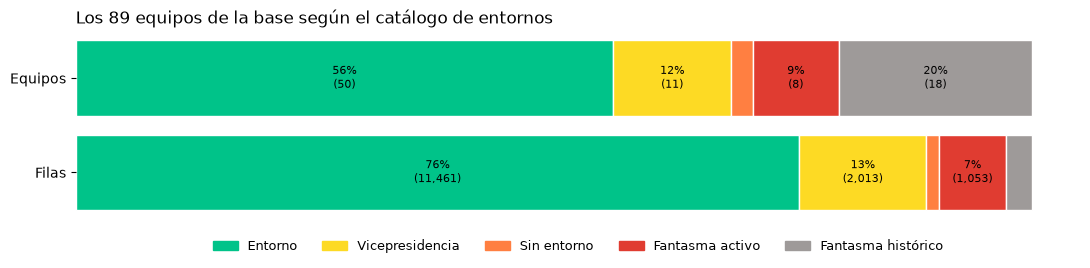

Entornos: 16 | equipos por entorno: mínimo 1, mediana 3, máximo 10


In [9]:
cat_entornos["tipo_padre"] = "Sin entorno"
cat_entornos.loc[cat_entornos["Codigo_Padre"].str.startswith("ENX"), "tipo_padre"] = "Entorno"
cat_entornos.loc[cat_entornos["Codigo_Padre"].str.startswith("VPX"), "tipo_padre"] = "Vicepresidencia"

equipos["ubicacion"] = equipos.index.map(cat_entornos.set_index("Codigo_EQU")["tipo_padre"])
equipos.loc[~equipos["en_catalogo"] & (equipos["ultimo_mes"] >= "202601"), "ubicacion"] = "Fantasma activo"
equipos.loc[~equipos["en_catalogo"] & (equipos["ultimo_mes"] < "202601"), "ubicacion"] = "Fantasma histórico"
grupos = {"Entorno": VERDE, "Vicepresidencia": AMARILLO, "Sin entorno": NARANJA, "Fantasma activo": ROJO, "Fantasma histórico": GRIS}
cantidades = pd.DataFrame({"Equipos": equipos["ubicacion"].value_counts(),
                           "Filas": equipos.groupby("ubicacion")["filas"].sum()}).reindex(list(grupos)).fillna(0)
proporciones = cantidades / cantidades.sum()

fig, ax = plt.subplots(figsize=(11, 2.8))
for j, medida in enumerate(["Filas", "Equipos"]):
    barra_apilada(ax, j, proporciones[medida], grupos, minimo=0.04,
                  texto=lambda grupo, valor, m=medida: f"{valor:.0%}\n({int(cantidades.loc[grupo, m]):,})" if valor > 0.04 else "")
ax.set_yticks([0, 1], ["Filas", "Equipos"])
ax.set_xticks([])
leyenda(ax, grupos)
ax.set_title(f"Los {len(equipos)} equipos de la base según el catálogo de entornos", loc="left")
limpiar_ejes(ax, ("top", "right", "left", "bottom"))
plt.tight_layout()
plt.show()

equipos_por_entorno = cat_entornos[cat_entornos["tipo_padre"] == "Entorno"].groupby("Nombre_Padre").size()
print(f"Entornos: {equipos_por_entorno.size} | equipos por entorno: mínimo {equipos_por_entorno.min()}, "
      f"mediana {equipos_por_entorno.median():.0f}, máximo {equipos_por_entorno.max()}")

**Lectura:** los equipos fantasma son 29% de los equipos pero solo 10% de las filas, porque la mayoría son históricos; los 8 activos sí deben agregarse al catálogo.

## 1.2.g Diferencias documentadas

| Pregunta | Respuesta |
|---|---|
| ¿Los indicadores medidos están en el catálogo? | **Solo 10 de 25 (40%)**. 1 está escrito distinto y 14 no aparecen: son el **54% de las filas** |
| ¿Todos los indicadores del catálogo se miden? | **No: 2 de 13 nunca se miden**, con la misma definición (índice consolidado de agilidad) |
| ¿Los frentes de la base están en el catálogo? | **No todos**: "Talento + Agilidad" no aparece, y "Modeos…" es un error de digitación que viene del catálogo |
| ¿Los códigos de equipo son confiables? | **146 formas de escribir 89 equipos** |
| ¿Los equipos medidos existen en el catálogo? | **63 de 89 (71%)**: 26 fantasma, 18 históricos y **8 activos en 2026** |
| ¿Todos los equipos del catálogo se miden? | 63 de 64: EQU00023 no tiene mediciones |
| ¿Cada equipo tiene un entorno? | **Solo 56% (50 de 89)**: 11 cuelgan de una vicepresidencia y 2 están "sin entorno" |